# 📊 03. 데이터 통계 + 인사이트 리포트 — H&M 커머스

> 엔코아 AI캠퍼스 · 데이터 분석 & AI 머신러닝 캠프

이 노트북은 **01_데이터이해_전처리 → 02_데이터_EDA → 03_데이터_통계(이 노트북)** 3파트 파이프라인의 **마지막**입니다. 02 에서 관찰만 하고 넘긴 질문("이 차이가 우연인지")을 여기서 통계로 확인하고, 프로젝트를 **인사이트 리포트**로 마무리합니다.

**구성**
1. **정제본 불러오기** — 01 이 만든 표를 그대로 이어 씁니다. 맨 위 선언 셀에서 라이브러리와 폰트를 한 번 준비해 두면 끝까지 씁니다. **어떤 함수를 쓸지는 day08·09 교안과 공식 문서에서 직접 찾으세요.**
2. **선택 통계 미션 카탈로그** — ⚠️ **통계는 필수가 아닙니다.** 발제문의 필수 목표는 EDA·시각화·인사이트입니다. 이 절은 "차이가 우연인지까지 따지고 싶은 사람"을 위한 **선택**이며, **2~3개만 골라도 충분**합니다.
3. **최종 인사이트 리포트** — 이 프로젝트의 마무리, **필수**입니다.
4. **AI 협업 검증** — 오류가 심어진 AI 초안을 실제로 재계산해 잡아내는 실습입니다.
5. **제출 체크리스트** — 발제문 필수 목표를 다 담았는지 스스로 확인합니다.

## 1. 정제본 불러오기
01 이 저장한 정제본(`output/hm_clean.csv`)을 읽습니다. **원본 3개 테이블은 다시 읽지 않습니다.**

### 준비 ① 도구 챙기기 — 어떤 라이브러리를 왜 쓰나
이 노트북은 **코드를 주지 않습니다.** 각 절이 *무엇을* 해야 하는지와 *어떤 도구*를 쓰는지 알려 주니, 코드는 그것을 보고 **직접** 쓰세요. 아래 표의 도구를 **바로 다음 셀에서 한 번만 선언**해 두면 끝까지 씁니다 — 뒤 절에서는 다시 import 하지 않습니다.

| 무엇에 쓰나 | 어떤 도구(관례 별칭) |
| --- | --- |
| 표·집계·수치 | `pandas`(`pd`) · `numpy`(`np`) |
| 그림 | `matplotlib.pyplot`(`plt`) · `seaborn`(`sns`) |
| 추정·카이제곱 적합도 | `scipy` 의 `stats` |
| 가정 점검·검정·효과크기·사후검정 | `pingouin`(`pg`) |
| 비모수 사후검정(Dunn) | `scikit_posthocs`(`sp`) — pingouin 에 없습니다 |
| 회귀·잔차 진단 | `statsmodels` 의 `formula.api`(`smf`)·`durbin_watson`·`het_breuschpagan` |
| 카이제곱 사후분석(조정된 잔차) | `statsmodels` 의 `Table` |

**한글 폰트**도 여기서 정해 두세요 — 안 하면 그래프의 한글이 □□□ 로 깨집니다. `platform.system()` 으로 OS 를 보고 Windows 는 `'Malgun Gothic'`, macOS 는 `'AppleGothic'`, 리눅스·Colab 은 `'NanumGothic'` 을 `plt.rcParams['font.family']` 에 넣고, `plt.rcParams['axes.unicode_minus']` 를 `False` 로 두어 마이너스 부호 깨짐도 막습니다. `sns.set_theme(...)` 은 폰트 설정을 되돌리므로 **set_theme 에 `font=` 로 같은 폰트를 넘기거나, set_theme 뒤에 폰트를 다시 지정**하세요. 01·02 의 준비 셀과 같은 내용이라 그대로 가져와도 됩니다.

> 🔧 **막히면**: 경고 메시지가 너무 많으면 `warnings.filterwarnings('ignore')` 로 눌러 둘 수 있습니다(통계 라이브러리는 참고용 경고를 자주 냅니다).

In [1]:
# ── 이 노트북에서 쓸 도구를 여기서 한 번만 선언합니다 (뒤 절에서 다시 import 하지 않습니다) ──
#   pandas(pd) · numpy(np) · matplotlib.pyplot(plt) · seaborn(sns)
#   scipy 의 stats · pingouin(pg) · scikit_posthocs(sp)
#   statsmodels.formula.api(smf) · durbin_watson · het_breuschpagan · Table
#   한글 폰트: platform.system() 으로 OS 판별 -> plt.rcParams['font.family'],
#             plt.rcParams['axes.unicode_minus'] = False,
#             sns.set_theme(..., font=<같은 폰트>) 로 되돌림 방지

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings

from scipy import stats
import pingouin as pg
import scikit_posthocs as sp
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

if platform.system() == 'Windows':
    KOREAN_FONT = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    KOREAN_FONT = 'AppleGothic'
else:
    KOREAN_FONT = 'NanumGothic'

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font=KOREAN_FONT, rc={'axes.unicode_minus': False})
warnings.filterwarnings('ignore')

### 준비 ② 정제본을 `df` 라는 이름으로 불러오기
- **무엇을**: 01 이 저장한 정제본 `output/hm_clean.csv` 를 `pd.read_csv` 로 읽습니다. **변수명은 `df`** 로 두세요 — 이 노트북의 모든 지침이 `df` 를 가정합니다. 읽은 뒤 `df.shape` 와 `df.head()` 로 무엇이 들어왔는지 먼저 확인합니다(데이터를 보지 않고 검정부터 하지 않습니다).
- **필요한 컬럼**: `t_dat`(거래일) · `age` · `price` · `sales_channel_id` · `club_member_status` · `product_group_name` · `customer_id`. 하나라도 없으면 **01 로 돌아가** 그 컬럼을 남긴 채 다시 저장하세요(원본 3개 테이블을 여기서 다시 읽지는 않습니다).
- **날짜형 복구**: CSV 를 거치면 `t_dat` 가 문자열로 풀립니다 → `pd.to_datetime` 으로 되돌리세요. 안 하면 뒤에서 `.dt` 접근이 실패합니다.
- **파생 컬럼(이름 그대로 만드세요)**: `month` = `t_dat` 의 월(`.dt.month`), `age_group` = 10년 단위 연령대(`age // 10 * 10`, 정수형). 요일까지 보고 싶으면 `weekday`(`.dt.dayofweek`)를 더해도 됩니다. 무거운 그림·계산에 쓸 표본이 필요하면 `df_s` 를 하나 만들어 두면 편합니다(3000행, `random_state=42` 로 고정하면 매번 같은 표본).

> ⚠️ **정제 규칙이 기준값을 바꿉니다** — 이 노트북에 적어 둔 기대값(예: 채널 t≈64.9, 4절 자가채점의 74.7%)은 **01 의 표준 규칙**을 적용한 **113,218행** 기준입니다: 중복 제거 · 나이 10~99세만 남김 · `price > 0` · `sales_channel_id` 는 `isin([1, 2])`(정의에 없는 코드 `0` 제외) · `club_member_status` 결측은 `fillna('Unknown')`. 여러분이 다른 규칙을 골랐다면 숫자가 조금씩 다를 수 있고 **그건 틀린 게 아닙니다**(01 에 이유를 적어 두었다면). 다만 **4절 자가채점만은** 위 규칙에 맞춰 두세요.

In [2]:
# ── 쓸 도구 ─────────────────────────────────────────
#   pd.read_csv('output/hm_clean.csv') -> 변수명은 df (이 노트북의 모든 지침이 df 를 가정)
#   pd.to_datetime(df['t_dat'])  — CSV 를 거치면 문자열로 풀립니다
#   파생: month = .dt.month · age_group = age // 10 * 10 (정수형)
#   무거운 계산용 표본: df_s = df.sample(n=3000, random_state=42)
#   확인: df.shape · df.head()

df = pd.read_csv('output/hm_clean.csv')
df['t_dat'] = pd.to_datetime(df['t_dat'])
df_s = df.sample(n=3000, random_state=42)

print(df.shape)
display(df.head())

(114544, 38)


,t_dat,customer_id,article_id,price,sales_channel_id,FN,Active,club_member_status,fashion_news_frequency,age,...,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc,is_zero_price,month,weekday,age_group
0,2019-01-01,80d8c96835c3aaf25a5b2bc306d9747bbd4601fd75bc65...,542677002,0.050831,2,0,0,ACTIVE,NONE,30,...,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Body in lace and mesh with underwired, thickly...",False,1,Tuesday,30
1,2019-01-01,a105c61ed98470b3dbed27f1bdfc584d09d20762efe680...,665201002,0.010153,2,1,1,ACTIVE,Regularly,21,...,Sport,5,Ladies H&M Sport,1005,Jersey Fancy,Short sports shorts in fast-drying functional ...,False,1,Tuesday,20
2,2019-01-01,05e0e58672ee73b047e510dbf974ce1870f92b71f5f6ac...,629061002,0.089983,2,0,0,ACTIVE,NONE,35,...,Ladieswear,14,Womens Premium,1003,Knitwear,"Jumper in soft, fine-knit cashmere with long, ...",False,1,Tuesday,30
3,2019-01-01,09a33e5dab855528c7dad33a4119b68102aa91c37a9e25...,554704005,0.030492,2,1,1,ACTIVE,Regularly,58,...,Divided,53,Divided Collection,1007,Outdoor,Long jacket in jersey with narrow notch lapels...,False,1,Tuesday,50
4,2019-01-01,58bb1e01b9e8e592bef5ea8e2dbe587fc3ca290b55e976...,572400002,0.023712,2,0,0,Unknown,NONE,46,...,Divided,51,Divided Basics,1002,Jersey Basic,Long-sleeved top in sweatshirt fabric with a j...,False,1,Tuesday,40


## 2. 선택 통계 미션 카탈로그
⚠️ **다시 한 번 — 통계는 필수가 아닙니다.** 발제문의 필수 목표는 EDA·시각화·인사이트입니다. 아래 미션은 **검정을 스스로 고르고 함수를 직접 찾아** 해 보는 연습이며, **2~3개만 골라도 충분**합니다.

| # | 미션 | 난이도 | 도구 | 예상 시간 |
| --- | --- | --- | --- | --- |
| A | 채널별 단가 차이 검정 | ★★ | `pg.homoscedasticity`·`pg.ttest` | 15분 |
| B | 연령대별 단가 차이 + 사후검정 *(02 연계)* | ★★★ | `pg.anova`/`welch_anova`·사후검정 | 20분 |
| C | 연령대 × 채널 독립성 검정 *(02 연계)* | ★★★ | `pg.chi2_independence`·조정잔차 | 20분 |
| D | 멤버십별 단가 차이 검정 | ★★★ | `pg.anova`·`pg.pairwise_tukey` | 20분 |
| E | 고객 총구매액 회귀 + LINE 진단 | ★★★ | `smf.ols`·잔차 진단 | 25분 |

### 미션 A — 채널별 단가 차이 검정
온라인·오프라인의 평균 단가가 정말 다른지 **가정 점검 → 검정 선택 → 실행**의 전 과정을 **직접** 작성해 보세요 — 가정 점검부터 검정 선택까지 스스로 판단해야 합니다.

> ✅ **이런 결과면 잘 된 것**: 등분산 점검 결과에 맞는 t-검정을 고르면 T 값이 약 64.9 근처로 나옵니다.
> 🔧 **막히면 볼 곳**: day08·09 교안에서 해당 검정을 찾아보세요 — (가정 점검)·(t-검정)

,count,mean,std
sales_channel_id,,,
1,35046,0.022651,0.015342
2,78887,0.029692,0.020394


온라인이 오프라인의 1.31배


,W,pval,normal
sales_channel_id,,,
1,0.841284,6.004418e-37,False
2,0.800370,4.417025e-54,False


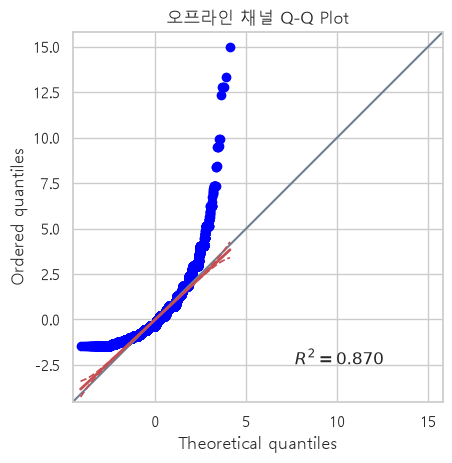

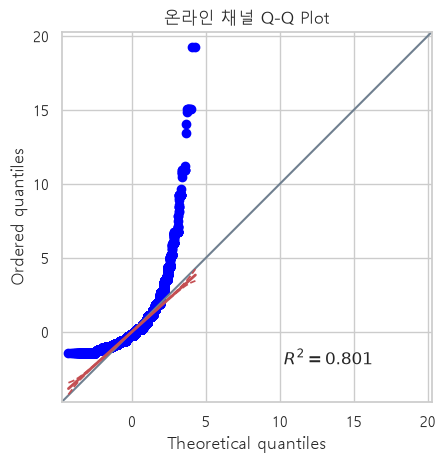

,W,pval,equal_var
levene,602.062401,1.320011e-132,False


equal_var=False -> 등분산 위반


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,64.307079,87662.378339,two-sided,0.0,"[0.01, 0.01]",0.370904,1.0,inf


In [3]:
# 채널 0 제외
d = df[df['sales_channel_id'] != 0]
off = d[d['sales_channel_id'] == 1]['price']   # 오프라인
on  = d[d['sales_channel_id'] == 2]['price']   # 온라인
# display(on)

# 건수, 평균, 표준편차
# print(f'오프라인 건수: {len(off)}건, 평균: {off.mean():.3f}, 표준편차: {off.std():.3f}')
# print(f'온라인 건수: {len(on)}건, 평균: {on.mean():.3f}, 표준편차: {on.std():.3f}')
display(d.groupby('sales_channel_id')['price'].agg(['count', 'mean', 'std']))
print(f'온라인이 오프라인의 {on.mean() / off.mean():.2f}배')

# 가정 점검 (정규성)
display(pg.normality(d.sample(5000, random_state=42), dv='price', group='sales_channel_id'))
ax1 = pg.qqplot(off)
ax1.set_title('오프라인 채널 Q-Q Plot')
plt.show()
ax2 = pg.qqplot(on)
ax2.set_title('온라인 채널 Q-Q Plot')
plt.show()

# levene: 두 집단의 흩어진 정도가 같은지 확인하는 검사 (등분산 검사)
# 온라인의 표준편차가 더 큰데 얼마나 더 넓게 퍼져있는지 판정해주는 검사, equal_var=False면 다르다는 판정
display(pg.homoscedasticity(d, dv='price', group='sales_channel_id'))
print('equal_var=False -> 등분산 위반')

# t-검정에는 두 종류가 있는데,
# Student: 두 집단의 퍼짐이 같다고 믿고 계산 
# Welch: 퍼짐이 달라도 알아서 처리 (선택) / correction=True를 사용
display(pg.ttest(on, off, correction=True))


- 검정 선택 이유: `pg.normality` 결과 두 집단 모두 `normal=False`이고 Q-Q Plot에서도 오른쪽 꼬리가 직선을 크게 벗어난다. 다만 각 집단의 표본이 3.5만·7.9만으로 충분히 커 중심극한정리에 의해 평균의 분포는 정규에 근사하므로, 등분산 위반에 맞춰 **Welch t-검정**을 사용한다.

- 결과: 온라인 평균단가가 오프라인의 평균단가보다 약 1.31배 높다. Welch t-검정 결과  T = 64.31, p < 0.001 이므로 이는 유의하다. 그러나 효과크기는 0.371로 작은~중간 수준이다. 표본이 크기 때문에 p값이 극단적으로 작게 나오지만 실제 차이의 크기는 크지 않다.
마케팅 관점에서 온라인 단가가 높다는 방향성은 활용할 수 있으나 온라인이 압도적이라는 해석은 피해야 한다. 또한 이 데이터는 온라인 기록이 더 많이 수집된 표본이라 채널 비중 자체에 편향 가능성이 있다.

### 미션 B — 연령대별 단가 차이 + 사후검정
02 의 질문 — "연령대별 평균 단가 차이가 통계적으로 유의한가?" — 를 **직접** 검정하세요. 정규성·등분산을 점검하고, 그 결과에 맞는 ANOVA(또는 Welch-ANOVA)와 사후검정을 실행하세요.

> ✅ **이런 결과면 잘 된 것**: F 값이 약 55(Welch) 근처, η² 는 0.01 미만(매우 작음)으로 나오고, 사후검정에서 36쌍 중 절반가량이 유의하게 나오면 됩니다.
> 🔧 **막히면 볼 곳**: day08·09 교안에서 해당 검정을 찾아보세요 — (가정 점검 선택표)·(ANOVA/Welch-ANOVA)

,count,mean,std
age_group,,,
10,1956,0.023186,0.014377
20,46971,0.026809,0.017946
30,23315,0.027650,0.020199
40,17807,0.027199,0.019257
50,19135,0.029055,0.020588
60,4524,0.030500,0.021733
70,768,0.030524,0.022497
80,62,0.030038,0.018850
90,6,0.020195,0.012259


연령대가 오를수록 평균값이 오르고 있다.


,W,pval,normal
age_group,,,
40,0.804143,4.867856e-30,False
20,0.886457,2.632486e-36,False
30,0.795920,2.433599e-33,False
60,0.938075,2.113404e-07,False
50,0.807547,5.074384e-31,False
10,0.893509,6.548180e-06,False
70,0.706683,8.976211e-06,False
80,NaN,NaN,False


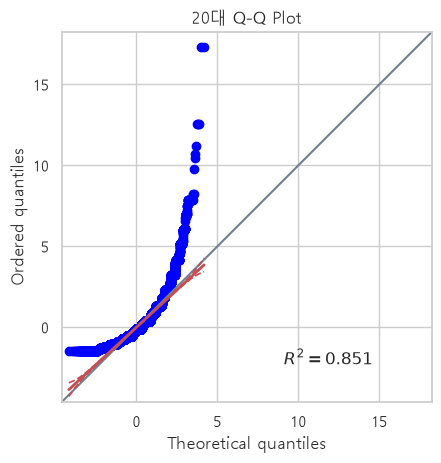

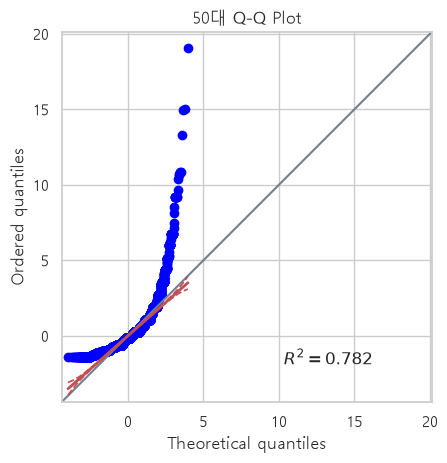

normal -> False이고 Q-Q Plot에서도 정규성이 깨져있는 것을 볼 수 있다. 
표본이 커서 평균이 안정적이기 때문에 비모수가 아닌 모수 검정을 그대로 쓴다.


,W,pval,equal_var
levene,22.554869,8.897619e-35,False


equal_var=False (W=22.55, p<0.001), 연령대마다 가격이 흩어진 정도가 다르다는 뜻 
→ 그래서 일반 ANOVA가 아니라 등분산 위반하여 Welch ANOVA를 고름


,Source,ddof1,ddof2,F,p_unc,np2
0,age_group,8,122.089178,55.120357,6.057803e-37,0.003665


F=55.12, p<0.001 -> 연령대 간 차이는 유의하다.
그러나 효과크기 0.0037 로 작음 기준(0.01)에도 못 미쳐 실질적 의미는 거의 없다.


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,10,20,0.023186,0.026809,-0.003623,0.000335,-10.799085,2216.518398,0.000000e+00,-0.203326
1,10,30,0.023186,0.027650,-0.004463,0.000351,-12.717070,2649.949685,9.079404e-13,-0.225304
2,10,40,0.023186,0.027199,-0.004012,0.000356,-11.280791,2789.569193,0.000000e+00,-0.213060
3,10,50,0.023186,0.029055,-0.005869,0.000358,-16.414587,2847.678227,0.000000e+00,-0.292068
4,10,60,0.023186,0.030500,-0.007314,0.000458,-15.957209,5433.661396,1.165290e-12,-0.369291
5,10,70,0.023186,0.030524,-0.007338,0.000874,-8.391422,1022.401929,3.848033e-13,-0.429987
8,20,30,0.026809,0.027650,-0.000841,0.000156,-5.386206,41965.019794,2.580200e-06,-0.044895
10,20,50,0.026809,0.029055,-0.002246,0.000170,-13.187672,31579.603781,0.000000e+00,-0.119796
11,20,60,0.026809,0.030500,-0.003691,0.000334,-11.066364,5134.435555,0.000000e+00,-0.201598
12,20,70,0.026809,0.030524,-0.003715,0.000816,-4.553040,783.041463,2.107054e-04,-0.206082


전체 쌍: 36
유의한 쌍: 17


In [4]:
display(df.groupby('age_group')['price'].agg(['count', 'mean', 'std']))
print('연령대가 오를수록 평균값이 오르고 있다.')

display(pg.normality(df.sample(5000, random_state=42), dv='price', group='age_group'))

agg20 = df[df['age_group'] == 20]['price']   # 20대
agg50  = df[df['age_group'] == 50]['price']  # 50대
ax3 = pg.qqplot(agg20)
ax3.set_title('20대 Q-Q Plot')
plt.show()
ax4 = pg.qqplot(agg50)
ax4.set_title('50대 Q-Q Plot')
plt.show()
print('normal -> False이고 Q-Q Plot에서도 정규성이 깨져있는 것을 볼 수 있다. \n표본이 커서 평균이 안정적이기 때문에 비모수가 아닌 모수 검정을 그대로 쓴다.')

display(pg.homoscedasticity(df, dv='price', group='age_group'))
print('equal_var=False (W=22.55, p<0.001), 연령대마다 가격이 흩어진 정도가 다르다는 뜻 \n→ 그래서 일반 ANOVA가 아니라 등분산 위반하여 Welch ANOVA를 고름')

# 집단이 3개 이상이면 t-검정 대신 ANOVA를 쓰고, 등분산이 깨졌으니 Welch ANOVA
# 어디가 다른지만 알려줌
display(pg.welch_anova(data=df, dv='price', between='age_group'))
print('F=55.12, p<0.001 -> 연령대 간 차이는 유의하다.\n그러나 효과크기 0.0037 로 작음 기준(0.01)에도 못 미쳐 실질적 의미는 거의 없다.')

# 사후검정으로 어디가 다른지 알기 위해 Games-Howell 사용
gh = pg.pairwise_gameshowell(data=df, dv='price', between='age_group')
display(gh[gh['pval'] < 0.05])
print('전체 쌍:', len(gh))
print('유의한 쌍:', (gh['pval'] < 0.05).sum())

사후검정 결과 36쌍 중 17쌍이 유의했다. 그러나 효과크기(hedges)를 함께 보면 10대가 포함된 쌍만 −0.29~−0.43으로 상대적으로 크고, 나머지 쌍은 −0.045~−0.2 수준에 그친다. 특히 20대와 30대는 유의하지만 효과크기가 −0.045로 사실상 차이가 없다.

즉 실질적으로 구분되는 것은 10대의 단가가 다른 연령대보다 낮다는 점 하나이며, 20~70대 사이는 통계적으로 유의해도 마케팅 타깃을 나눌 근거로 삼기 어렵다.

### 미션 C — 연령대 × 채널 독립성 검정
02 의 두 번째 질문 — "연령대와 채널 선호가 독립적인가?" — 를 카이제곱 독립성 검정으로 확인하세요. **기대빈도가 5 이상인지** 먼저 확인하고, 부족하면 연령대를 묶어 다시 검정하세요. Cramér's V 와 조정된 잔차까지 확인하세요.

> ✅ **이런 결과면 잘 된 것**: 그룹핑 후 최소 기대빈도가 5 이상이 되고, χ² 는 유의(p≈0)하지만 Cramér's V 는 0.1 미만(약함)으로 나오면 됩니다.
> 🔧 **막히면 볼 곳**: day08·09 교안에서 해당 검정을 찾아보세요 — (카이제곱)

In [5]:
# 여기에 코드를 작성하세요

### 미션 D — 멤버십별 단가 차이 검정
채널·연령대와는 다른 축인 **멤버십 상태(`club_member_status`)** 별로 단가가 다른지 검정하세요. 이번엔 등분산이 만족되는 경우인지 직접 확인해 보세요(은 연령대만 다뤘습니다).

> ✅ **이런 결과면 잘 된 것**: 등분산이 만족되어 일반 ANOVA를 쓰면 F 는 약 9 근처, p 는 유의하지만 η² 는 0.001 미만(극히 작음)으로 나오고, 사후검정에서는 딱 한 쌍만 유의하게 나오면 됩니다.
> 🔧 **막히면 볼 곳**: day08·09 교안에서 해당 검정을 찾아보세요 — (가정 점검)·(ANOVA)

In [6]:
# 여기에 코드를 작성하세요

### 미션 E — 고객 총구매액 회귀 + LINE 진단
고객별 총구매액을 나이·구매빈도·온라인비중으로 설명하는 **다중회귀**를 적합하고, LINE 4가정을 잔차로 진단하세요(지침대로 만든 `cust`·`m_multi` 를 그대로 이어 써도 됩니다).

> ✅ **이런 결과면 잘 된 것**: R² 는 약 0.38, 세 계수 모두 p<0.001 로 유의하고, Durbin-Watson 은 2 근처(독립성 OK)지만 Breusch-Pagan p 는 사실상 0(등분산 위배)으로 나오면 됩니다.
> 🔧 **막히면 볼 곳**: day08·09 교안에서 해당 검정을 찾아보세요 — (회귀·LINE 진단)

In [7]:
# 여기에 코드를 작성하세요

## 3. 최종 인사이트 리포트 (필수)
여기부터는 **선택이 아닙니다.** 01→02→03 에서 본 것을 하나의 리포트로 묶는, 이 프로젝트의 마무리입니다.

**리포트 뼈대 — 다섯 조각**
1. **무엇을 물었나** — 이 분석의 질문·가설(00 에서 세운 비즈니스 목표와 연결).
2. **어떻게 봤나** — 데이터·처리 규칙 요약(무엇을 지우고 무엇을 남겼는지, 그 이유).
3. **무엇을 발견했나** — 수치 + 그래프로 뒷받침되는 핵심 발견 2~4개(통계를 했다면 p·효과크기도).
4. **그래서 무엇을 하나** — 발견을 실행 가능한 제안으로(누구에게·무엇을·어떻게).
5. **한계** — 이 결론을 과신하면 안 되는 이유.

**숫자를 말로 옮기는 법** — ③ 발견을 쓸 때는 항상 이 순서를 따르세요.
1. **숫자 재진술** — 무엇을 비교했고 값이 얼마였는지 있는 그대로 적는다.
2. **유의성 + 효과크기** — p-value(우연인지)와 Cohen's d·η²·Cramér's V(크기)를 함께 적는다.
3. **방향** — 그래서 무엇이 더/덜 한지 한 문장으로 정리한다.

이때 두 가지를 절대 헷갈리지 마세요 — **유의 ≠ 실질**(p 가 작다고 차이가 큰 것은 아님, 특히 표본이 클 때)과 **상관 ≠ 인과**(같이 움직인다고 한쪽이 다른 쪽의 원인은 아님)입니다.

**좋은 예 / 나쁜 예**

| | 나쁜 예 | 좋은 예 |
| --- | --- | --- |
| 발견 | "온라인이 잘 팔린다" | "온라인 평균 단가가 오프라인보다 **약 1.3배**(0.0299 vs 0.0228) 높고, 이 차이는 통계적으로 유의하며 효과크기(Cohen's d=0.376)도 작은~중간 수준이다." |
| 제안 | "마케팅을 더 하자" | "단가가 높은 온라인 채널에 매출 상위 상품군(상의류) 노출을 강화하고, 가입 대기(PRE-CREATE) 고객 대상 온라인 온보딩을 설계한다." |
| 한계 | (언급 없음) | "이 데이터는 **Kaggle 이 공개한 표본**이라 전체 H&M 고객이 아니고, **관찰 자료라 인과가 아니며**, `price` 는 실제 화폐가 아닌 **정규화된 상대값**이다." |

**한계·해석 규율 — 어떤 결론을 쓰든 빠뜨리면 안 되는 여섯 가지**
- **매출의 정의(수량이 없다)**: 거래 표에 **수량(quantity) 컬럼이 없습니다.** 그래서 `price` 를 더한 값은 엄밀히 "매출액"이 아니라 **"구매 단가의 총합"** 입니다 — 리포트에 이 말을 그대로 적어 두세요. 게다가 이 값은 실제 화폐가 아니라 **0~1 사이로 정규화된 상대값**입니다(직접 `df['price'].min()`·`max()`·`mean()` 으로 확인해 보세요). "1,000원"처럼 절대 금액으로 읽거나 통화 단위를 붙여 쓰면 안 됩니다. 참고로 발제문에는 통화 단위를 언급하라고 적혀 있지만 이 데이터의 `price` 는 그 서술과 맞지 않습니다 — **문서와 데이터가 다를 때는 데이터를 믿고, 그 차이를 리포트에 적으세요.**
- **표본 편향**: 이 데이터는 Kaggle 이 공개한 **일부 표본**입니다 — 특히 **온라인(`sales_channel_id=2`) 기록이 상대적으로 많이 담겨** 있어 채널 비중이 실제보다 온라인 쪽으로 왜곡돼 있을 수 있습니다. 그래서 채널·집단을 비교할 때는 **건수 그대로가 아니라 비율(%)이나 고객당 평균 구매액(ARPU)으로 보정**해 비교하세요.
- **상관 ≠ 인과**: 연령대·채널·멤버십과 단가 사이의 관계는 원인이 아니라 **관찰된 결과**입니다. "20대 단가가 높다 → 20대를 집중 타깃으로" 같은 도약을 하지 마세요(무작위 배정 실험이 아니므로 "온라인이라서 비싸졌다"도 말할 수 없습니다). 제안은 "이 세그먼트에서 **검증해 볼 가치가 있다**" 수준으로 씁니다.
  · 참고로 발제문은 이 대목에서 **성별**을 예로 들며 "20대 여성" 을 언급하지만, 이 데이터의 고객 테이블에는 **성별 컬럼이 아예 없습니다**(`customer_id`·`FN`·`Active`·`club_member_status`·`fashion_news_frequency`·`age` 6개). 발제문에 적힌 변수가 실제로 있는지 **직접 확인하고** 없으면 "이 표본에는 성별 정보가 없어 분석하지 못했다"고 한계에 적으세요.
- **시즌성**: 특정 월의 급증을 **"성장"으로 단정하지 마세요.** 블랙프라이데이·연말연시 같은 이벤트가 반영돼 있을 수 있습니다. 추세를 말하려면 여러 기간을 비교하거나 롤링 평균처럼 노이즈를 줄인 뒤 말하세요.
- **인기 ≠ 트렌드 선도**: 상품군·색상의 매출 상위는 **공급량·재고 정책·프로모션**의 결과일 수 있습니다. "상의류가 1위"는 사실이지만 "상의류가 트렌드를 이끈다"는 이 데이터로 말할 수 없습니다.
- **인플레이션·환율 미반영**: 시점별 물가·환율 차이가 보정되지 않았으므로 **절대적 추세 해석은 제한적**입니다 — 같은 시점 안에서의 **상대 비교**에 초점을 두세요.

**리포트 템플릿** — 아래 빈칸을 채우세요.

In [8]:
# 코드가 아니라 서술입니다 — 아래 마크다운 셀에 리포트를 작성하세요.

*(① 무엇을 물었나)*

*(② 어떻게 봤나 — 데이터·처리 규칙 요약)*

*(③ 무엇을 발견했나 — 수치+그래프 근거, 통계를 했다면 p·효과크기도)*

*(④ 그래서 무엇을 하나 — 실행 가능한 제안)*

*(⑤ 한계 — 위 여섯 가지(매출의 정의·표본 편향·상관≠인과·시즌성·인기≠트렌드·물가·환율)를 반드시 포함)*

# 최종 인사이트 리포트
### ① 무엇을 물었나
마케팅팀의 타깃 프로모션 전략 수립을 위해, 채널·연령대·시기별로 결제금액 패턴이 어떻게 다른지 확인하고자 했다.

- 가설 1 — H0: 채널 간 평균 단가에 차이가 없다 / H1: 차이가 있다
- 가설 2 — H0: 연령대 간 평균 단가에 차이가 없다 / H1: 차이가 있다

### ② 어떻게 봤나
Kaggle H&M 표본 3개 테이블(거래 150,500 / 고객 95,516 / 상품 30,503)을 customer_id·article_id로 inner join해 116,973행을 만든 뒤, 다음 규칙으로 정제해 114,544행을 얻었다.

| 처리 | 내용 | 제거 |
| --- | --- | --- |
| 완전 중복 행 | 제거 | 539 |
| 멤버십 결측 | `Unknown` 으로 보존 | 0 |
| LEFT CLUB | 제외 | 53 |
| 나이 | 10~99세만 | 1,837 |
| 가격 0 이하 | 플래그 후 유지 | 0 |
| 채널 코드 0 | 유지 (채널 분석 시에만 제외) | 0 |
나이 이상치는 IQR·Z-score가 10세 미만 921명을 한 명도 걸러내지 못해 도메인 기준을 직접 적용했다. 가격 0원(1,004건)은 사은품일 가능성이 있어 지우지 않고 플래그로 표시했다.

### ③ 무엇을 발견했나
#### 발견 1 — 온라인 단가가 높지만 격차는 크지 않다
온라인 평균 단가 0.0297, 오프라인 0.0227로 1.31배 차이다. Welch t-검정 결과 유의했으나(T = 64.31, p < 0.001), 효과크기는 Cohen's d = 0.371로 작은~중간 수준이다.

#### 발견 2 — 연령대는 타깃 분할 기준으로 약하다
연령대별 평균 단가는 0.0232(10대)에서 0.0305(60·70대)로 오르고 Welch ANOVA에서 유의했으나(F = 55.12, p < 0.001), η² = 0.0037로 "작음" 기준(0.01)에도 못 미친다. 사후검정 36쌍 중 17쌍이 유의했지만 효과크기가 의미 있는 것은 10대가 포함된 쌍뿐이다.

#### 발견 3 — 가입 대기 고객은 온라인에만 있다
PRE-CREATE 고객은 구매의 99.9%가 온라인에서 발생했다(2,215건 중 오프라인 2건). ACTIVE(68.6%)·Unknown(69.3%)과 뚜렷이 구분되는 유일한 집단이다.

#### 발견 4 — 매출이 오르는 방식이 시기마다 다르다
6월은 총매출 341.8로 연중 최고지만 평균 단가는 0.0254로 낮다(건수 13,465건, 연중 최다). 반면 9·11월은 건수가 적은데도 평균 단가가 0.0323으로 가장 높다. 6월은 건수가, 9·11월은 단가가 매출을 만들었다.

### ④ 그래서 무엇을 하나
- **가입 전환 캠페인은 온라인 접점에 집중** — PRE-CREATE 2,215건이 사실상 전부 온라인이므로, 오프라인 매장 가입 유도는 이 집단에 닿지 않는다.
- **프로모션 시기를 두 갈래로 설계** — 6월형(방문·구매 빈도 유도)과 9·11월형(고가 상품 노출 강화)을 구분한다.
- **연령대가 아닌 다른 축으로 타깃을 나눈다** — 연령대별 단가 차이는 유의하지만 실질적 크기가 없다. 구매 빈도(고객의 83%가 연 1건)나 채널을 기준으로 삼는 편이 낫다.

### ⑤ 한계
- **표본 편향** — Kaggle 공개 표본이라 H&M 전체 고객이 아니며, 온라인 기록이 상대적으로 많이 수집되어 채널 비중 자체가 과대평가되었을 수 있다.
- **상관 ≠ 인과** — 관찰 데이터이므로 "가입 대기라서 온라인만 쓴다"인지 "온라인만 써서 가입 대기로 남았다"인지 구분할 수 없다. 연령대별 단가 차이도 나이 자체가 아니라 선호 상품군의 차이일 수 있다.
- **price의 정의** — 정규화된 상대값이며 수량 컬럼이 없어, 합계는 매출이 아니라 "구매 단가의 총합"이다. 또한 2019년 1년치라 계절성과 성장을 구분할 수 없다.
- **인기 ≠ 트렌드 선도** — 상품군 매출 상위는 공급량·재고 정책·프로모션의 결과일 수 있어, 상위 상품군이 트렌드를 이끈다고 말할 수 없다.
- **인플레이션·환율 미반영** — 시점별 물가·환율이 보정되지 않아 절대적 추세 해석은 제한적이며, 같은 시점 안의 상대 비교에 초점을 둔다.

## 4. AI 협업 검증
리포트 초안 작성에 AI(챗봇형 도구)를 쓰면 빠르지만, AI 는 **숫자·인과·연관 강도를 그럴듯하게 지어내거나 과장할 수 있습니다(환각)**. 여기서는 실제 API 호출 없이, **이미 오류가 심어진 AI 초안을 직접 재계산해 잡아내는 연습**을 합니다.

**① 좋은 프롬프트 4요소** — 맥락(무슨 데이터·무슨 분석인지) + 수치(내가 가진 정확한 값) + 요청(무엇을 써 달라는지) + 형식(불릿·길이 등), 그리고 "**준 수치 외의 값은 지어내지 말 것**"을 마지막에 덧붙이면 환각을 줄일 수 있습니다.

## 5. 제출 체크리스트
제출 전, 발제문의 **필수 목표**를 다 담았는지 스스로 확인하세요(체크만 하는 절이라 자가채점은 없습니다).

| # | 항목 | 어디서 |
| --- | --- | --- |
| 1 | 비즈니스 목표 세우기 | `01_데이터이해_전처리` 1장 |
| 2 | 데이터 소스 설명 | `01_데이터이해_전처리` 2장 |
| 3 | [EDA] 규모 파악 | `01_데이터이해_전처리` |
| 4 | [EDA] 타입과 기술통계 | `01_데이터이해_전처리` 2장 + `02_데이터_EDA` |
| 5 | [전처리] 테이블 결합 | `01_데이터이해_전처리` |
| 6 | [전처리] 규칙 수립·실행(이유 포함) | `01_데이터이해_전처리` |
| 7 | [분석·시각화] 기준 컬럼 비교 + 3개 이상 그림 | `02_데이터_EDA` + `03_데이터_통계` |
| 8 | [인사이트] 최소 1개 이상, 수치·그래프·해석 | `02_데이터_EDA` + `03_데이터_통계` |
